# Customer Churn Prediction — Baseline Model

## 1. Подготовка данных

### 1.1 Импорт библиотек

Подключаем библиотеки для работы с данными и построения модели.

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

### 1.2 Загрузка данных

Загружаем исходный набор данных и выполняем необходимую предварительную обработку.

In [22]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.3 Преобразование TotalCharges

Признак `TotalCharges` в исходном наборе имеет строковый тип. 
Преобразуем его в числовой формат.

Пустые значения после преобразования соответствуют клиентам с `tenure = 0`, 
поэтому заменяем их на 0.

In [23]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df["TotalCharges"] = df['TotalCharges'].fillna(0)

In [24]:
df['TotalCharges'].dtype

dtype('float64')

## 2. Формирование признаков и целевой переменной

Целевая переменная `Churn` преобразуется в бинарный формат:

- `No` → 0 — клиент остался;
- `Yes` → 1 — клиент ушёл.

Идентификатор клиента `customerID` исключается из признаков, 
поскольку не содержит полезной информации для прогнозирования.

In [25]:
y = df["Churn"].map({
    "No": 0,
    "Yes" : 1
})

X = df.drop(
    columns=["Churn", "customerID"]
)



In [26]:
print(y.shape)

print(X.shape)

print("\nTarget:")

print(y.value_counts())

(7043,)
(7043, 19)

Target:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 3. Разделение данных

Разделяем данные на обучающую и тестовую выборки в соотношении 80/20.

Параметр `stratify=y` сохраняет исходное соотношение классов `Churn`
в обеих выборках.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 19)
(5634,)
(1409, 19)
(1409,)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


### Результат

Обучающая выборка содержит 5634 наблюдения, тестовая — 1409.
Соотношение классов в обеих выборках практически совпадает.

## 4. Предварительная обработка признаков

Признаки разделяются на числовые и категориальные.

Числовые признаки будут масштабированы с помощью `StandardScaler`.

Категориальные признаки будут преобразованы методом One-Hot Encoding.

In [29]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.to_list()

categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.to_list()

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Числовые признаки:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Категориальные признаки:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 4.1 Масштабирование и кодирование

Для числовых признаков используется `StandardScaler`, поскольку
Logistic Regression чувствительна к масштабу признаков.

Для категориальных признаков используется `OneHotEncoder`,
поскольку категории не имеют числового порядка.

`handle_unknown="ignore"` позволяет корректно обрабатывать категории,
которые могут отсутствовать в обучающей выборке.

`drop="first"` исключает одну категорию из каждой группы и предотвращает
избыточность dummy-признаков.

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
            handle_unknown='ignore',
            drop="first"
        ),
        categorical_features
        )
    ]
)

## 5. Обучение baseline-модели

В качестве первой модели используется логистическая регрессия.

Модель обучается на обучающей выборке. Предварительная обработка признаков
выполняется внутри `Pipeline`, поэтому параметры масштабирования и кодирования
вычисляются только на обучающих данных.

In [31]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=10000))
    ]
)


In [32]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

## 6. Предсказание на тестовой выборке

После обучения модели получаем предсказанные классы для тестовой выборки.
Значение `0` соответствует клиенту, который остался, а `1` — клиенту, который ушёл.

In [33]:
y_pred = baseline_model.predict(X_test)

In [34]:
y_pred[:30]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1])

In [35]:
y_proba = baseline_model.predict_proba(X_test)[:,1]

In [36]:
y_proba

array([0.0458386 , 0.68375823, 0.06007238, ..., 0.15420197, 0.00444228,
       0.00642594], shape=(1409,))

In [37]:
results = pd.DataFrame({
    "actual": y_test.values,
    "probability" : y_proba,
    "prediciton" : y_pred
}
)
results.head(10)

,actual,probability,prediciton
0,0,0.045839,0
1,0,0.683758,1
2,0,0.060072,0
3,0,0.399365,0
4,0,0.021614,0
5,0,0.602268,1
6,0,0.447143,0
7,0,0.128906,0
8,0,0.002897,0
9,1,0.396051,0


### 6.1 Матрица ошибок

Для оценки результатов классификации используется матрица ошибок
(Confusion Matrix).

Матрица показывает количество объектов, для которых модель:

- правильно определила класс 0 — True Negative (TN);
- ошибочно определила класс 1 вместо 0 — False Positive (FP);
- ошибочно определила класс 0 вместо 1 — False Negative (FN);
- правильно определила класс 1 — True Positive (TP).

В `sklearn` строки соответствуют фактическим классам, а столбцы —
предсказанным:

\[
\begin{pmatrix}
TN & FP\\
FN & TP
\end{pmatrix}
\]

Для полученной модели:

\[
\begin{pmatrix}
927 & 108\\
164 & 210
\end{pmatrix}
\]

Таким образом:

- \(TN=927\);
- \(FP=108\);
- \(FN=164\);
- \(TP=210\).

In [38]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[927 108]
 [164 210]]


### 6.2 Основные метрики классификации

На основе матрицы ошибок рассчитываются основные метрики качества
классификации: Accuracy, Precision, Recall и F1-score.

**Accuracy** показывает долю правильных предсказаний среди всех объектов:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Precision** показывает, какая доля клиентов, которых модель
отнесла к ушедшим, действительно ушла:

$$
Precision=\frac{TP}{TP+FP}
$$

**Recall** показывает, какую долю реально ушедших клиентов модель
смогла обнаружить:

$$
Recall=\frac{TP}{TP+FN}
$$

**F1-score** является гармоническим средним Precision и Recall:

$$
F_1=
2\frac{Precision\cdot Recall}
{Precision+Recall}
$$

In [39]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.807
Precision: 0.660
Recall:    0.561
F1-score:  0.607


### 6.3 Результаты baseline-модели

Получены следующие значения метрик на тестовой выборке:

| Метрика | Значение |
|---|---:|
| Accuracy | 0.807 |
| Precision | 0.660 |
| Recall | 0.561 |
| F1-score | 0.607 |

Модель правильно классифицировала около 80.7% объектов тестовой выборки.

Precision равен 0.660, то есть среди клиентов, которых модель
отнесла к ушедшим, около 66.0% действительно относятся к классу
ушедших клиентов.

Recall равен 0.561: модель обнаружила около 56.1% клиентов,
которые действительно ушли.

F1-score равен 0.607 и характеризует совместный баланс между
Precision и Recall.

Полученные значения используются как исходный уровень качества
для последующего сравнения с другими моделями и настройками.

## 7. ROC-кривая и ROC-AUC

ROC-кривая показывает изменение True Positive Rate (Recall)
и False Positive Rate при изменении порога классификации.

Для построения ROC-кривой используются вероятности принадлежности
к положительному классу, полученные с помощью `predict_proba()`.

Площадь под ROC-кривой обозначается как ROC-AUC.

In [40]:
fpr, tpr , thresholds = roc_curve(
    y_test,
    y_proba
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print(f"ROC-AUC: {roc_auc:.3f}")


ROC-AUC: 0.842


### 7.2 Результат ROC-AUC

Для baseline-модели получено:

ROC-AUC = 0.842


ROC-AUC оценивает способность модели различать ушедших и оставшихся
клиентов по величине прогнозируемой вероятности, рассматривая различные
пороги классификации.

Полученное значение используется как исходный показатель качества
для последующего сравнения с другими моделями.

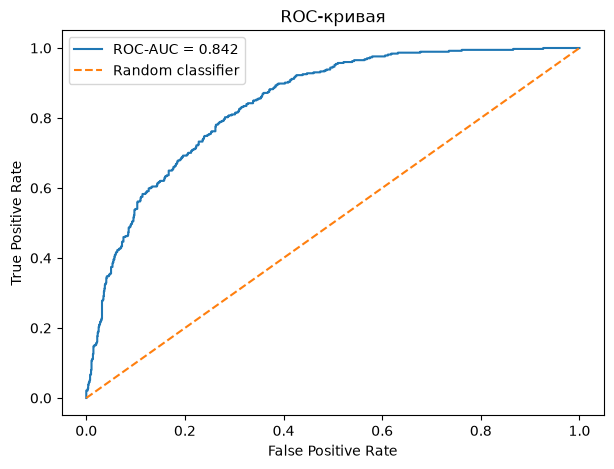

In [42]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

### 7.3 Интерпретация ROC-кривой

На графике представлена ROC-кривая baseline-модели.

По оси X находится False Positive Rate (FPR), а по оси Y —
True Positive Rate (TPR), который соответствует Recall.

Пунктирная диагональ соответствует случайному классификатору.
Чем выше ROC-кривая располагается над диагональю и чем ближе она
к левому верхнему углу графика, тем лучше модель разделяет классы.

Для baseline-модели значение ROC-AUC составляет:

$$
ROC\text{-}AUC = 0.842
$$

Это указывает на достаточно хорошую способность модели различать
клиентов, которые уйдут, и клиентов, которые останутся.

При этом ROC-AUC не зависит от выбора одного конкретного порога
классификации, в отличие от Accuracy, Precision, Recall и F1-score,
рассчитанных при threshold = 0.5.

## 8. Итоговая оценка baseline-модели

В качестве baseline использована логистическая регрессия с предварительной
обработкой числовых и категориальных признаков.

Числовые признаки стандартизируются с помощью `StandardScaler`, а
категориальные преобразуются в бинарные признаки с помощью `OneHotEncoder`.

Качество модели оценивается при стандартном пороге классификации
$threshold = 0.5$ с помощью Accuracy, Precision, Recall и F1-score.
Дополнительно используется ROC-AUC, который оценивает способность модели
разделять два класса независимо от выбора одного порога.

In [43]:
baseline_metrics = pd.DataFrame({
    "Metrics" : [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
    
})

baseline_metrics

,Metrics,Value
0,Accuracy,0.806955
1,Precision,0.660377
2,Recall,0.561497
3,F1-score,0.606936
4,ROC-AUC,0.842171


 ### Вывод

Baseline-модель показывает ROC-AUC = 0.842. При стандартном пороге
$threshold = 0.5$ получены Accuracy = 0.807, Precision = 0.660,
Recall = 0.561 и F1-score = 0.607.

Полученные значения фиксируются как исходный уровень качества модели.
В следующем этапе проекта будут исследованы способы улучшения
результатов и проведено сравнение с baseline.